# Visium-HD Pre-process v3
https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-human-lung-cancer-if

In [3]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

env: ANYWIDGET_HMR=1


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import celldega as dega
from ipywidgets import Widget
from pathlib import Path
import os
import json
import h5py
import matplotlib.pyplot as plt
from PIL import Image
from copy import deepcopy

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


# Pre-process LandscapeFiles

In [5]:
# dataset = 'Visium_HD_Mouse_Lung_Fresh_Frozen_binned_outputs'

dataset = 'Visium_HD_Human_Lung_Cancer'
base_path = 'data/visium-hd_data/' + dataset + '/binned_outputs/square_008um/'
landscape_files_path = 'data/landscape_files/' + dataset

# Tile Positions

In [4]:
df_pos = pd.read_parquet(base_path + 'spatial/tissue_positions.parquet')
df_pos = df_pos[df_pos['in_tissue'] == 1]
print (df_pos.shape)
print (f'Total number of spots: {df_pos.shape[0]/1e6} M')
df_pos.head()

(605471, 6)
Total number of spots: 0.605471 M


,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
60,s_008um_00000_00060-1,1,0,60,4455.255106,19771.540493
61,s_008um_00000_00061-1,1,0,61,4455.410118,19746.924147
62,s_008um_00000_00062-1,1,0,62,4455.565131,19722.307801
63,s_008um_00000_00063-1,1,0,63,4455.720143,19697.691455
64,s_008um_00000_00064-1,1,0,64,4455.875156,19673.075109


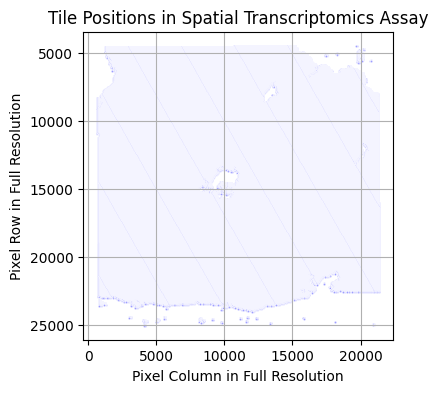

In [5]:
# Plotting
plt.figure(figsize=(4, 4))
plt.scatter(df_pos['pxl_col_in_fullres'], df_pos['pxl_row_in_fullres'], c='blue', alpha=0.6, edgecolors='w', s=2)
plt.title('Tile Positions in Spatial Transcriptomics Assay')
plt.xlabel('Pixel Column in Full Resolution')
plt.ylabel('Pixel Row in Full Resolution')
plt.gca().invert_yaxis()  # Invert y-axis to match the image coordinates
plt.grid(True)
plt.show()

In [6]:
filepath_scalefactors = base_path + 'spatial/scalefactors_json.json'
with open(filepath_scalefactors) as file:
    data = json.load(file)
scale_factor = data['tissue_hires_scalef']

data

{'spot_diameter_fullres': 24.616732333013957,
 'bin_size_um': 8.0,
 'microns_per_pixel': 0.3249822068898662,
 'regist_target_img_scalef': 0.24899365,
 'tissue_lowres_scalef': 0.024899365,
 'fiducial_diameter_fullres': 1015.4402087368256,
 'tissue_hires_scalef': 0.24899365}

In [7]:
df_pos['x_scaled'] = df_pos['pxl_col_in_fullres'] * scale_factor
df_pos['y_scaled'] = df_pos['pxl_row_in_fullres'] * scale_factor

print(df_pos.x_scaled.min(), df_pos.x_scaled.max())
print(df_pos.y_scaled.min(), df_pos.y_scaled.max())

print (df_pos.shape)

166.29113698017858 5319.122746611531
1109.330230448846 6239.840157345033
(605471, 8)


In [8]:
# Sample 10% of the rows randomly
df_sample = df_pos.sample(frac=0.01)
df_sample.shape

(6055, 8)

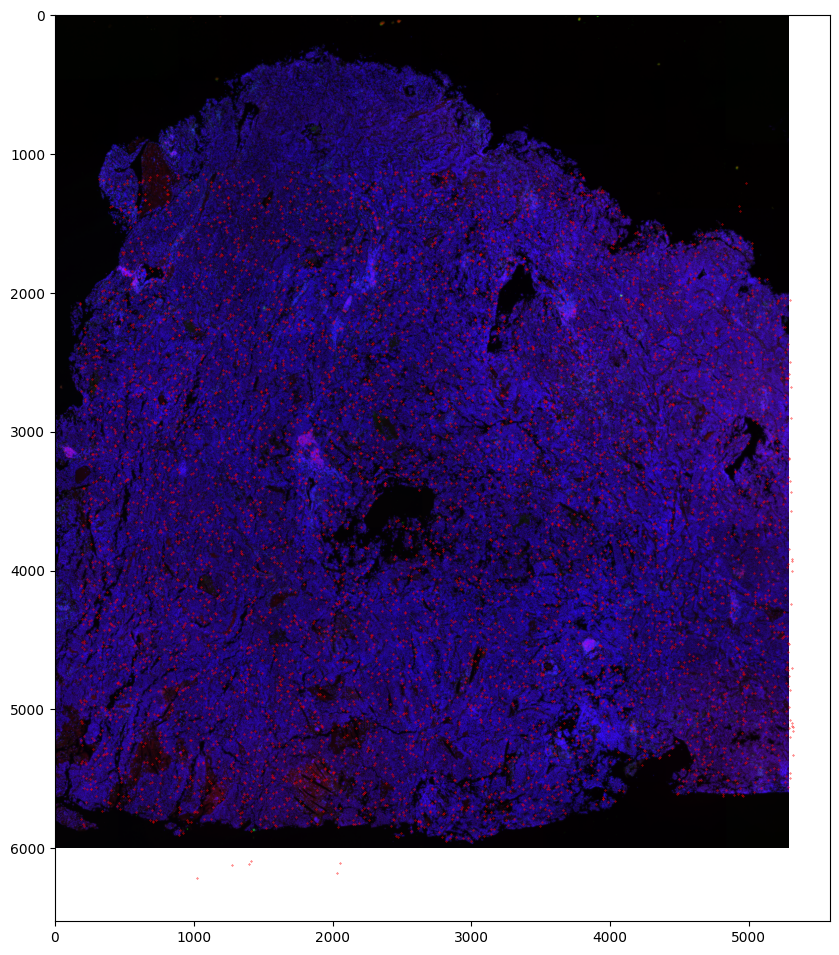

In [54]:
img = Image.open(f'{base_path}/spatial/tissue_hires_image.png')
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img)
ax.scatter(df_sample['x_scaled'], df_sample['y_scaled'], color='red', s=0.1, alpha=1)
plt.show()

In [11]:
meta_tile = pd.read_csv(base_path + 'analysis/clustering/gene_expression_graphclust/clusters.csv')
meta_tile.head(5)

,Barcode,Cluster
0,s_008um_00301_00321-1,2
1,s_008um_00602_00290-1,3
2,s_008um_00425_00829-1,4
3,s_008um_00728_00006-1,1
4,s_008um_00526_00291-1,2


In [12]:
from matplotlib.colors import to_hex
# Get all categorical color palettes from Matplotlib and flatten them into a single list of colors
palettes = [plt.get_cmap(name).colors for name in plt.colormaps() if "tab" in name]
flat_colors = [color for palette in palettes for color in palette]

# Convert RGB tuples to hex codes
flat_colors_hex = [to_hex(color) for color in flat_colors]

In [13]:
meta_tile['Cluster'].value_counts()

Cluster
1     210464
2     151506
3      96681
4      54645
5      33464
6      15888
7      14905
8      11751
9       9195
10      6932
Name: count, dtype: int64

In [14]:
if not os.path.exists(landscape_files_path):
    os.mkdir(landscape_files_path)

In [15]:
clusters = [str(x) for x in meta_tile['Cluster'].unique().tolist()]

# Use modular arithmetic to assign a color to each gene, white for genes with "Blank"
colors = [flat_colors_hex[i % len(flat_colors_hex)] if "Blank" not in cluster else "#FFFFFF" for i, cluster in enumerate(clusters)]

# Create a DataFrame with genes and their assigned colors
df_colors = pd.DataFrame({'color': colors}, index=clusters)
df_colors.to_parquet(f"{landscape_files_path}/df_colors.parquet")
df_colors.head()

,color
2,#1f77b4
3,#ff7f0e
4,#2ca02c
1,#d62728
9,#9467bd


In [16]:
# meta_tile_json = meta_tile.to_json(orient='records')
meta_tile_json = dict(zip(meta_tile['Barcode'], meta_tile['Cluster']))
json_output = json.dumps(meta_tile_json)

with open(f"{landscape_files_path}/meta_tile.json", 'w') as file:
    file.write(json_output)

meta_tile.head()

,Barcode,Cluster
0,s_008um_00301_00321-1,2
1,s_008um_00602_00290-1,3
2,s_008um_00425_00829-1,4
3,s_008um_00728_00006-1,1
4,s_008um_00526_00291-1,2


In [17]:
tile = pd.DataFrame()
tile['name'] = df_pos['barcode']

# tile['center_x'] = df_pos['pxl_col_in_fullres'].round(1)
# tile['center_y'] = df_pos['pxl_row_in_fullres'].round(1)

tile['center_x'] = df_pos['x_scaled'] # .round(1)
tile['center_y'] = df_pos['y_scaled'] # .round(1)

tile['center_x'] = tile['center_x'].astype(float)
tile['center_y'] = tile['center_y'].astype(float)

In [18]:

path_tile_geo = f"{landscape_files_path}/tile_geometries.parquet"
# pd.read_parquet(path_tile_geo).head()

In [19]:
tile_merge = deepcopy(tile)
tile_merge.index = tile['name'].values.tolist()
display(tile_merge.head())

meta_tile_merge = deepcopy(meta_tile)
meta_tile_merge.index = meta_tile['Barcode'].values.tolist()
display(meta_tile_merge.head())

,name,center_x,center_y
s_008um_00000_00060-1,s_008um_00000_00060-1,4922.988033,1109.330230
s_008um_00000_00061-1,s_008um_00000_00061-1,4916.858720,1109.368828
s_008um_00000_00062-1,s_008um_00000_00062-1,4910.729406,1109.407425
s_008um_00000_00063-1,s_008um_00000_00063-1,4904.600092,1109.446022
s_008um_00000_00064-1,s_008um_00000_00064-1,4898.470778,1109.484619


,Barcode,Cluster
s_008um_00301_00321-1,s_008um_00301_00321-1,2
s_008um_00602_00290-1,s_008um_00602_00290-1,3
s_008um_00425_00829-1,s_008um_00425_00829-1,4
s_008um_00728_00006-1,s_008um_00728_00006-1,1
s_008um_00526_00291-1,s_008um_00526_00291-1,2


In [20]:
cats = [str(x) for x in meta_tile_merge['Cluster'].values.tolist()]
keep_tiles = meta_tile_merge.index.tolist()
tile_merge.loc[keep_tiles, 'cluster'] = pd.Series(cats, index=keep_tiles)
tile_merge.to_parquet(f'{landscape_files_path}/meta_tile.parquet')
display(tile_merge.head())
print (tile_merge.center_x.mean(), tile_merge.center_y.mean())

,name,center_x,center_y,cluster
s_008um_00000_00060-1,s_008um_00000_00060-1,4922.988033,1109.330230,10
s_008um_00000_00061-1,s_008um_00000_00061-1,4916.858720,1109.368828,10
s_008um_00000_00062-1,s_008um_00000_00062-1,4910.729406,1109.407425,10
s_008um_00000_00063-1,s_008um_00000_00063-1,4904.600092,1109.446022,4
s_008um_00000_00064-1,s_008um_00000_00064-1,4898.470778,1109.484619,10


2676.9249353724213 3527.270794103648


In [21]:
tile_merge['geometry'] = tile_merge.apply(lambda row: [row['center_x'], row['center_y']], axis=1)
tile_merge.loc[keep_tiles, ['name', 'geometry', 'cluster']].to_parquet(path_tile_geo)
display(tile_merge.head())

,name,center_x,center_y,cluster,geometry
s_008um_00000_00060-1,s_008um_00000_00060-1,4922.988033,1109.330230,10,"[4922.988033460872, 1109.330230448846]"
s_008um_00000_00061-1,s_008um_00000_00061-1,4916.858720,1109.368828,10,"[4916.858719531121, 1109.3688275963268]"
s_008um_00000_00062-1,s_008um_00000_00062-1,4910.729406,1109.407425,10,"[4910.729405679816, 1109.4074247433136]"
s_008um_00000_00063-1,s_008um_00000_00063-1,4904.600092,1109.446022,4,"[4904.60009190696, 1109.4460218898068]"
s_008um_00000_00064-1,s_008um_00000_00064-1,4898.470778,1109.484619,10,"[4898.4707782125515, 1109.4846190358055]"


In [22]:
file_path = base_path + 'filtered_feature_bc_matrix.h5'

In [23]:
# def print_structure(file, indent = ' '):
#     """Recursively prints the groups and datasets in an HDF5 file."""
#     for key in file.keys():
#         item = file[key]
#         print(indent, key)
#         if isinstance(item, h5py.Dataset):
#             print(indent + ' ', "Dataset")
#         elif isinstance(item, h5py.Group):
#             print_structure(item, indent + ' ')

# with h5py.File(file_path, 'r') as file:
#     print_structure(file)


# Read Tile-by-Gene Sparse Matrix

In [24]:
import pandas as pd
from scipy.io import mmread
from scipy.sparse import csr_matrix

In [25]:
def make_unique(names):
    from collections import Counter
    counts = Counter(names)
    new_names = []
    used_names = {}

    for name in names:
        if counts[name] > 1:  # If this name is a duplicate
            if name in used_names:
                used_names[name] += 1
            else:
                used_names[name] = 1
            new_name = f"{name}-{used_names[name]}"
        else:
            new_name = name
        new_names.append(new_name)

    return new_names

In [26]:
%%time
# File paths
barcodes_path = base_path + 'filtered_feature_bc_matrix/barcodes.tsv.gz'
features_path = base_path + 'filtered_feature_bc_matrix/features.tsv.gz'
matrix_path = base_path + 'filtered_feature_bc_matrix/matrix.mtx.gz'

# Read barcodes and features
barcodes = pd.read_csv(barcodes_path, header=None, compression='gzip')
features = pd.read_csv(features_path, header=None, compression='gzip', sep='\t')

# Read the gene expression matrix and transpose it
matrix = mmread(matrix_path).transpose().tocsc()  # Transpose and convert to CSC

# Create a sparse DataFrame with genes as columns and barcodes as rows
tbg = pd.DataFrame.sparse.from_spmatrix(matrix, index=barcodes[0], columns=features[1])
tbg.columns = make_unique(tbg.columns.tolist())

print(tbg.shape)
tbg.columns.tolist()[:10]

(605471, 18085)
CPU times: user 15.6 s, sys: 981 ms, total: 16.5 s
Wall time: 8.2 s


['SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'PERM1',
 'HES4',
 'ISG15',
 'AGRN',
 'RNF223',
 'C1orf159']

In [27]:
meta_tile = pd.read_parquet(f'{landscape_files_path}/meta_tile.parquet')
meta_tile.head()

,name,center_x,center_y,cluster
s_008um_00000_00060-1,s_008um_00000_00060-1,4922.988033,1109.330230,10
s_008um_00000_00061-1,s_008um_00000_00061-1,4916.858720,1109.368828,10
s_008um_00000_00062-1,s_008um_00000_00062-1,4910.729406,1109.407425,10
s_008um_00000_00063-1,s_008um_00000_00063-1,4904.600092,1109.446022,4
s_008um_00000_00064-1,s_008um_00000_00064-1,4898.470778,1109.484619,10


In [28]:
tbg.head()

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
0,,,,,,,,,,,,,,,,,,,,,
s_008um_00301_00321-1,0,0,0,0,0,0,0,0,0,0,...,7,1,1,1,1,2,1,2,0,2
s_008um_00602_00290-1,0,0,0,0,0,0,0,0,0,0,...,1,5,2,0,0,1,3,0,1,1
s_008um_00425_00829-1,0,0,0,0,0,0,0,0,0,0,...,1,2,1,2,0,1,3,0,0,1
s_008um_00728_00006-1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,3,0,0,1
s_008um_00526_00291-1,0,0,0,0,0,0,0,0,0,0,...,3,10,6,0,2,3,5,2,0,2


In [29]:
gene_exp = tbg.sum()

In [30]:
%%time
# Calculate mean expression across tiles with float precision
print('calculating mean expression from sparse float data')
mean_expression = tbg.astype(pd.SparseDtype("float", 0)).mean(axis=0)

# Calculate the variance as the average of the squared deviations
print('calculating variance by looping over rows')
num_tiles = tbg.shape[1]
variance = tbg.apply(lambda x: ((x - mean_expression[x.name]) ** 2).sum() / num_tiles, axis=0)
std_deviation = np.sqrt(variance)

# # Assuming mean_expression is aligned with columns
# print('calculating variance using vectorized approach')
# squared_deviations = (tbg - mean_expression) ** 2
# variance = squared_deviations.mean(axis=0)

# Calculate maximum expression
max_expression = tbg.max(axis=0)

# Calculate proportion of tiles with non-zero expression
proportion_nonzero = (tbg != 0).sum(axis=0) / len(tbg)

# Create a DataFrame to hold all these metrics
meta_gene = pd.DataFrame({
    'mean': mean_expression,
    'std': std_deviation,
    'max': max_expression,
    'non-zero': proportion_nonzero
})

calculating mean expression from sparse float data
calculating variance by looping over rows
CPU times: user 11 s, sys: 683 ms, total: 11.7 s
Wall time: 11.7 s


In [31]:
meta_gene.head()

,mean,std,max,non-zero
SAMD11,0.006288,0.462534,3,0.000002
NOC2L,0.013016,0.662700,2,0.000002
KLHL17,0.003865,0.359473,2,0.000002
PLEKHN1,0.000517,0.132778,2,0.000002
PERM1,0.000089,0.054641,1,0.000002


In [32]:
meta_gene['max'].sort_values(ascending=False).head(10)

IGKC      1637
IGHG3      641
IGHG1      538
IGHM       253
IGLC1      145
IGHA1       97
IGLC7       91
CARTPT      79
CHGB        69
CHGA        63
Name: max, dtype: Sparse[int64, 0]

In [33]:
# Convert only the sparse columns to dense
for column in meta_gene.columns:
    # Check if the column dtype is an instance of pd.SparseDtype
    if isinstance(meta_gene[column].dtype, pd.SparseDtype):
        meta_gene[column] = meta_gene[column].sparse.to_dense()

In [34]:
meta_gene.to_parquet(f'{landscape_files_path}/meta_gene.parquet')

In [35]:
%%time
mean_expression = tbg.astype(pd.SparseDtype("float", 0)).mean(axis=0)
mean_expression

CPU times: user 1.28 s, sys: 149 ms, total: 1.43 s
Wall time: 1.43 s


SAMD11     0.006288
NOC2L      0.013016
KLHL17     0.003865
PLEKHN1    0.000517
PERM1      0.000089
             ...   
MT-ND4L    3.152115
MT-ND4     4.479121
MT-ND5     0.813056
MT-ND6      0.31672
MT-CYB     2.945979
Length: 18085, dtype: Sparse[float64, 0]

In [36]:
mean_expression.sort_values(ascending=False).head(5)

IGKC        5.15006
MT-ND4     4.479121
MT-CO2     3.980627
CARTPT     3.909185
MT-ND4L    3.152115
dtype: Sparse[float64, 0]

# save tile-by-gene parquet files

In [ ]:
# # need to run this just commenting out to prevent re-running
# ################################################################
# output_dir = f'{landscape_files_path}/tbg/'
# os.makedirs(output_dir, exist_ok=True)

# for index, gene in enumerate(tbg.columns):
#     if index % 500 == 0:
#         print(index)
#     # Extract the column as a DataFrame
#     col_df = tbg[[gene]].copy()

#     col_df = col_df.sparse.to_dense()
#     # col_df.fillna(0, inplace=True)
#     col_df = col_df.astype(int)

#     inst_df = pd.DataFrame(col_df.values, columns=[gene], index=col_df.index.tolist())

#     inst_df = inst_df.loc[keep_tiles]
#     inst_df.replace(0, pd.NA, inplace=True)
#     inst_df.dropna(how='all', inplace=True)

#     # Save to Parquet
#     inst_df.to_parquet(os.path.join(output_dir, f'{gene}.parquet'))


15500
16000
16500
17000
17500
18000


In [37]:
pd.read_parquet(f'{landscape_files_path}/tbg/A1CF.parquet').head()

,A1CF
s_008um_00078_00444-1,1
s_008um_00035_00460-1,1
s_008um_00451_00702-1,1
s_008um_00141_00404-1,1
s_008um_00133_00239-1,1


### Make Image Pyramid

In [38]:
dega.pre.make_deepzoom_pyramid(
    base_path + 'spatial/tissue_hires_image.png',
    f'{landscape_files_path}/pyramid_images/',
    'cells',
    suffix=".webp[Q=100]"
)

In [39]:
# Example usage:
path_image_pyramid = f'{landscape_files_path}/pyramid_images/cells_files/'
max_pyramid_zoom = dega.pre.get_max_zoom_level(path_image_pyramid)

print(max_pyramid_zoom)

13


In [40]:
landscape_files_path.strip('/')

'data/landscape_files/Visium_HD_Human_Lung_Cancer'

In [41]:
image_info = {
        "name": "cells",
        "button_name": "CELLS",
        "color": [0, 0, 255]
    }

In [42]:
dega.pre.save_landscape_parameters(
    'Visium-HD',
    landscape_files_path,
    'cells_files',
    tile_size=100,
    image_info=image_info
)


========Save landscape parameters========
Done.


# Landscape Visualization

In [6]:
server_address = dega.viz.get_local_server()

In [7]:
base_url = f'http://localhost:{server_address}/data/landscape_files/' + dataset

In [8]:
Widget.close_all()

landscape_sst = dega.viz.Landscape(
    technology='Visium-HD',
    base_url=base_url,
    square_tile_size=3,
    height=600
)

landscape_sst

/var/folders/8d/jxpy9rd10j7fp2rcj_s5sz3c0000gq/T/ipykernel_62734/1293982380.py:3: UserWarning: Transformation matrix not found at http://localhost:53531/data/landscape_files/Visium_HD_Human_Lung_Cancer/micron_to_image_transform.csv. Using identity.
  landscape_sst = dega.viz.Landscape(


Landscape(base_url='http://localhost:53531/data/landscape_files/Visium_HD_Human_Lung_Cancer', cell_attr=['leid…

In [49]:
tbg.head()

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
0,,,,,,,,,,,,,,,,,,,,,
s_008um_00301_00321-1,0,0,0,0,0,0,0,0,0,0,...,7,1,1,1,1,2,1,2,0,2
s_008um_00602_00290-1,0,0,0,0,0,0,0,0,0,0,...,1,5,2,0,0,1,3,0,1,1
s_008um_00425_00829-1,0,0,0,0,0,0,0,0,0,0,...,1,2,1,2,0,1,3,0,0,1
s_008um_00728_00006-1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,3,0,0,1
s_008um_00526_00291-1,0,0,0,0,0,0,0,0,0,0,...,3,10,6,0,2,3,5,2,0,2


In [50]:
meta_tile.head()

,name,center_x,center_y,cluster
s_008um_00000_00060-1,s_008um_00000_00060-1,4922.988033,1109.330230,10
s_008um_00000_00061-1,s_008um_00000_00061-1,4916.858720,1109.368828,10
s_008um_00000_00062-1,s_008um_00000_00062-1,4910.729406,1109.407425,10
s_008um_00000_00063-1,s_008um_00000_00063-1,4904.600092,1109.446022,4
s_008um_00000_00064-1,s_008um_00000_00064-1,4898.470778,1109.484619,10


In [ ]:
list_ser = []

for inst_cluster in meta_tile.cluster.unique():

    if inst_cluster != None:
        keep_tiles = meta_tile[meta_tile.cluster == inst_cluster].index.tolist()
        print(inst_cluster, len(keep_tiles))
        tbg_subset = tbg.loc[keep_tiles]
        tbg_subset = tbg_subset.apply(lambda col: col.sparse.to_dense().astype(float) if pd.api.types.is_sparse(col) else col.astype(float))
        inst_ser = tbg_subset.mean()
        inst_ser.name = inst_cluster
        list_ser.append(inst_ser)


In [ ]:
df_sig = pd.concat(list_ser, axis=1)
# mat = dega.clust.Matrix(tbg.T, meta_col=meta_tile)
mat = dega.clust.Matrix(df_sig)
tmp = mat.cluster()
cgm = dega.viz.Clustergram(matrix=mat)

# Convert all sparse columns to dense
for col in df_sig.columns:
    if pd.api.types.is_sparse(df_sig[col]):
        df_sig[col] = df_sig[col].sparse.to_dense()
df_sig.to_parquet(landscape_files_path + '/df_sig.parquet')

(18085, 10)

## More dev from a different branch (PR 139)
https://github.com/broadinstitute/celldega/pull/139

In [74]:
import subprocess
import glob
from IPython.display import display, Markdown

def _visium_hd_unzipper(target_dir):
    """
    Unzips and extracts Xenium-related files in the specified directory.
    If the unzipped files already exist, the function skips those steps.

    Args:
        target_dir (str): Path to the directory containing the compressed files.

    Raises:
        subprocess.CalledProcessError: If any of the commands fail to execute.
        FileNotFoundError: If the target directory does not exist.
    """

    print("\n========Unzip and extract Visium-HD-related files========")
    # Check if the target directory exists
    if not os.path.exists(target_dir):
        raise FileNotFoundError(f"The directory '{target_dir}' does not exist.")

    # Save the current working directory
    original_dir = os.getcwd()

    try:
        # Change to the target directory
        os.chdir(target_dir)

        sample = target_dir.split('/')[-1]

        # Check if binned_output directory already exists
        if not os.path.exists(f"{sample}_binned_outputs"):
            subprocess.run(["tar", "-xvzf", f'{sample}_binned_outputs.tar.gz'], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        # Check if cell_feature_matrix directory already exists
        if not os.path.exists(f"{sample}_spatial"):
            subprocess.run(["tar", "-xvzf", f'{sample}_spatial.tar.gz'], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        # Check if cell_feature_matrix directory already exists
        if not os.path.exists(f"{sample}_segmented_outputs"):
            subprocess.run(["tar", "-xvzf", f'{sample}_segmented_outputs.tar.gz'], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        print("All files have been successfully extracted or skipped.")
    except subprocess.CalledProcessError as e:
        print(f"An error occurred while executing a command: {e}")
        raise
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        raise
    finally:
        # Restore the original working directory
        os.chdir(original_dir)


def sample_file_compare(path1, path2, file_nick_name):

    file_to_check = {
        "meta_cluster": "cell_clusters/meta_cluster.parquet",
        "cluster": "cell_clusters/cluster.parquet",
        "EPCAM": "cbg/EPCAM.parquet",
        "cell_tile": "cell_segmentation/cell_tile_1_*.parquet",
        "df_sig": "df_sig.parquet",
        "meta_gene": "meta_gene.parquet",
        "cell_metadata": "cell_metadata.parquet"
    }[file_nick_name]


    print(f"\n🔍 Checking: `{file_to_check}`")

    # Path 1
    match1 = glob.glob(f"{path1}/{file_to_check}")
    if match1:
        df1 = pd.read_parquet(match1[0])
        display(Markdown(f"**📁 Path 1: `{match1[0]}`**"))
        display(df1.head(3))
    else:
        print("⚠️ Not found in path 1")

    # Path 2
    match2 = glob.glob(f"{path2}/{file_to_check}")
    if match2:
        df2 = pd.read_parquet(match2[0])
        display(Markdown(f"**📁 Path 2: `{match2[0]}`**"))
        display(df2.head(3))
    else:
        print("⚠️ Not found in path 2")

In [75]:
sample = 'Visium_HD_Mouse_Embryo'
data_dir = f'data/visium-hd_data/{sample}'
path_landscape_files=f'data/landscape_files/{sample}'

# Reference Xenium landscape file dir
path_landscape_files_xenium = f'data/landscape_files/Xenium_V1_human_Pancreas_FFPE_outs'

## Load segmentation, load barcode, spatial join to get barcodes -> cell_id mapping

<string>:24: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326



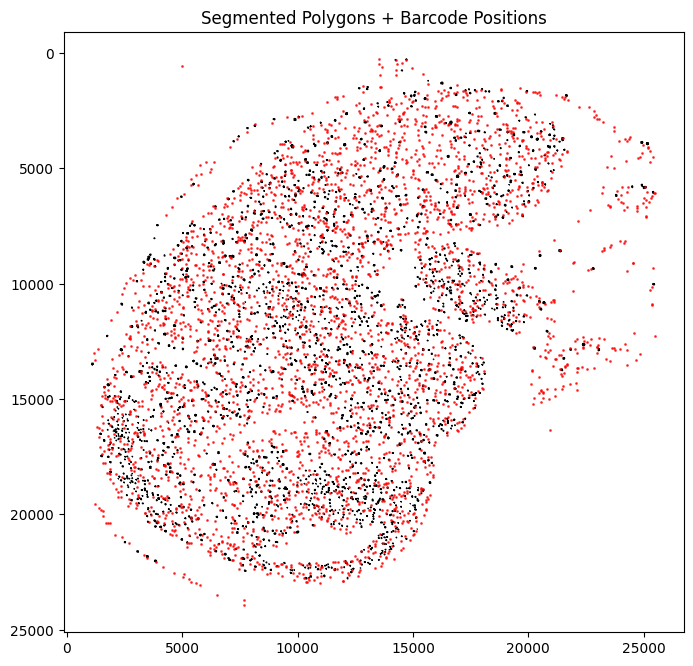

In [76]:
barcode_to_cell_dict, gdf_pos_join, gdf_cells, gdf_pos = dega.pre.create_barcode_to_cell_id_mapping(data_dir, micron_size)

gdf_sample = gdf_cells.sample(frac=0.01)
gdf_pos_sample = gdf_pos.sample(frac=0.01)

ax = gdf_sample.plot(aspect=1, edgecolor='black', linewidth=1, facecolor='none', figsize=(8, 8))
gdf_pos_sample.plot(ax=ax, color='red', markersize=1, alpha=0.7)
ax.invert_yaxis()
ax.set_title("Segmented Polygons + Barcode Positions")
ax.set_aspect('equal')
plt.show()

## Create cluster and meta cluster

In [77]:
default_clustering, clusters, ser_counts = dega.pre._load_visium_hd_cluster_data(base_path, barcode_to_cell_dict)
cell_clusters_dir = Path(path_landscape_files) / f"cell_clusters"
dega.pre._save_cluster_data(cell_clusters_dir, default_clustering, clusters, ser_counts)

sample_file_compare(path_landscape_files_xenium, path_landscape_files, 'cluster')
sample_file_compare(path_landscape_files_xenium, path_landscape_files, 'meta_cluster')


🔍 Checking: `cell_clusters/cluster.parquet`


**📁 Path 1: `data/landscape_files/Xenium_V1_human_Pancreas_FFPE_outs/cell_clusters/cluster.parquet`**

,cluster
aaaadnje-1,15
aaacalai-1,9
aaacjgil-1,15


**📁 Path 2: `data/landscape_files/Visium_HD_Mouse_Embryo/cell_clusters/cluster.parquet`**

,cluster
cell_id,
1,4
4,5
5,5



🔍 Checking: `cell_clusters/meta_cluster.parquet`


**📁 Path 1: `data/landscape_files/Xenium_V1_human_Pancreas_FFPE_outs/cell_clusters/meta_cluster.parquet`**

,color,count
1,#1f77b4,17949
2,#ff7f0e,15781
3,#2ca02c,14415


**📁 Path 2: `data/landscape_files/Visium_HD_Mouse_Embryo/cell_clusters/meta_cluster.parquet`**

,color,count
1,#1f77b4,70078
2,#ff7f0e,44924
3,#2ca02c,32685


## Tile-by-gene creation is not optimized yet and can be found here:
https://github.com/broadinstitute/celldega/blob/5342b9e07de9cd73ae6f79c0168a0d9d609e9bed/notebooks/_Visium-HD_pre-process_v2.ipynb